In [ ]:
import os
import random
import re
import time
import urllib.request
import webbrowser
from pathlib import Path

import cartopy.crs as ccrs
import folium
import geopandas as gpd
import geoplot as gplt
import geoplot.crs as gcrs
import googlemaps
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import seaborn.objects as so
from bs4 import BeautifulSoup
from openpyxl import load_workbook

pd.set_option("display.max_rows", 100)

path = Path(r"D:\Giving\School\CPAN-314\Housing Analysis\data")
neighbourhood_path = path.joinpath("neighbourhoods")
ttc_path = path.joinpath("ttc")
housing_path = path.joinpath("housing")

In [2]:
def fetch_sold_url():
    total_pages = 345
    links = pd.DataFrame(columns=["link"])
    curr_link = 0

    for page in range(1, total_pages + 1):
        user_agent = "Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:144.0) Gecko/20100101 Firefox/144.0"
        token = ""
        url = (
            "https://www.zolo.ca/index.php?s_r=3"
            if page == 1
            else f"https://www.zolo.ca/index.php/page-{page}?s_r=3"
        )
        headers = {"User-Agent": user_agent, "Cookie": f"token={token}"}

        request = urllib.request.Request(url, None, headers)
        raw = urllib.request.urlopen(request).read()
        soup = BeautifulSoup(raw, "html.parser")
        postings = soup.find_all("a", class_="address text-primary")

        for posting in postings:
            links.loc[curr_link] = str(posting.get("href"))
            curr_link += 1

        time.sleep(random.uniform(1, 4))
    links.to_csv(housing_path.joinpath("house_links.csv"), index=False)

In [103]:
# Populating the table with housing data
links = pd.read_csv(housing_path.joinpath("house_links.csv"))

if (p := housing_path.joinpath("housing.csv")).exists():
    houses = pd.read_csv(p)
else:
    houses = pd.DataFrame(
        columns=[
            "days_on_market",
            "sold_date",
            "sold_price",
            "age",
            "house_type",
            "house_style",
            "size",
            "area",
            "municipality",
            "neighbourhood",
            "list_price",
            "bedrooms",
            "bedrooms_plus",
            "bathrooms",
            "kitchens",
            "rooms",
            "den_or_family_room",
            "central_vac",
            "air_conditioning_type",
            "fireplace",
            "basement",
            "heating",
            "heating_type",
            "heating_fuel",
            "garage",
            "parking_places",
            "parking_total",
            "covered_parking_places",
            "mls",
            "address",
            "lat",
            "lon",
        ]
    )

In [ ]:
def normalize_feature(label):
    features = [
        "days_on_market",
        "sold_date",
        "sold_price",
        "age",
        "area",
        "municipality",
        "list_price",
        "bedrooms",
        "bedrooms_plus",
        "bathrooms",
        "kitchens",
        "rooms",
        "central_vac",
        "fireplace",
        "basement",
        "heating",
        "heating_type",
        "heating_fuel",
        "garage",
        "parking_places",
        "parking_total",
        "covered_parking_places",
        "address",
        "lat",
        "lon",
    ]
    feature_map = {
        "type": "house_type",
        "style": "house_style",
        "size (sq ft)": "size",
        "mls®#": "mls",
        "den/family room": "den_or_family_room",
        "air conditioning": "air_conditioning_type",
        "community": "neighbourhood",
    }
    temp_label = label.strip().lower()
    if temp_label in feature_map:
        return feature_map[temp_label]
    temp_label = "_".join(temp_label.split(" "))
    return temp_label if temp_label in features else None


def fetch_sold_details():
    skipped = []

    for i in range(links.shape[0]):
        try:
            if i > 0 and i % 250 == 0:
                time.sleep(random.uniform(60, 120))

            url = links.at[i, "link"]
            user_agent = "Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:144.0) Gecko/20100101 Firefox/144.0"
            token = ""
            headers = {"User-Agent": user_agent, "Cookie": f"token={token}"}

            request = urllib.request.Request(url, None, headers)
            raw = urllib.request.urlopen(request).read()
            soup = BeautifulSoup(raw, "html.parser")

            # Look for all features
            for label_dt in soup.find_all("dt", class_="column-label"):
                label_text = label_dt.text.strip().lower()

                feature_name = normalize_feature(label_text)
                if feature_name is None:
                    continue

                span = label_dt.find_next_sibling("dd").find("span")
                if not span:
                    continue
                feature_value = span.text.strip().lower()
                houses.at[i, feature_name] = feature_value

            for label_div in soup.find_all("div", class_="column-label"):
                label_text = label_div.text.strip().lower()

                feature_name = normalize_feature(label_text)
                if feature_name is None:
                    continue

                span = label_div.find_next_sibling("div").find("span")
                if not span:
                    continue
                feature_value = span.text.strip().lower()

                if feature_name == "heating":
                    if (
                        pd.isna(houses.at[i, "heating"])
                        or houses.at[i, "heating"] == ""
                    ):
                        houses.at[i, "heating"] = feature_value
                    else:
                        houses.at[i, "heating"] += f", {feature_value}"
                else:
                    houses.at[i, feature_name] = feature_value

            # Special features not in the description
            address = soup.find("h1", class_="address").text.strip().lower()
            houses.at[i, "address"] = address

            print("Progress:", i)
            print(len(houses))
            time.sleep(random.uniform(1, 3))
        except Exception as e:
            print(f"Skipped {i}: {e}")
            skipped.append(i)
            continue

    print("Total skipped:", len(skipped))


def geocode_loc():
    key = os.getenv("GOOGLE_API_KEY")
    gmaps = googlemaps.Client(key=key)

    for i, row in houses.iterrows():
        if not (pd.isna(row["lat"]) or pd.isna(row["lon"])):
            continue

        address = f'{row["address"]}, {row["neighbourhood"]}'
        geocode_result = gmaps.geocode(address)

        if geocode_result:
            loc = geocode_result[0]["geometry"]["location"]
            houses.at[i, "lat"] = loc["lat"]
            houses.at[i, "lon"] = loc["lng"]

        time.sleep(0.2)

In [8]:
def split_heating():
    split = houses["heating"].str.split(", ", n=1, expand=True)
    houses["heating_fuel"] = split[0]
    houses["heating_type"] = split[1]

    houses.drop(columns=["heating"], inplace=True)

# Neighbourhood Mapping

In [62]:
neighbourhoods = gpd.read_file(neighbourhood_path.joinpath("neighbourhoods.geojson"))

# Housing Statistics

- Neighbourhood Income (maybe household)
- Age (mean, median)
- Housings Prices projected on Neighbourhood Income
- Demographic (Language, Ethnicity)
- Population (Change, Total)
- Education
- Commuting (public transit access, commute time breakdown)
- Transit
- Listing

In [104]:
price_floor = houses["sold_price"].quantile(0.05)
houses = houses[houses["sold_price"] >= price_floor]

house_type_mapping = {
    "condo apartment": "Apartment",
    "co-op apartment": "Apartment",
    "co-ownership apartment": "Apartment",
    "detached": "Detached",
    "semi-detached": "Semi-Detached",
    "condo townhouse": "Townhouse",
    "att/row/townhouse": "Townhouse",
    "common element condo": "Townhouse",
    "link": "Townhouse",
    "duplex": "Multiplex",
    "triplex": "Multiplex",
    "fourplex": "Multiplex",
    "multiplex": "Multiplex",
}

houses.loc[:, "final_type"] = houses["house_type"].map(house_type_mapping)
houses = houses.dropna(subset=["final_type"])
houses = houses.drop(columns=["house_type"])
houses = houses.rename(columns={"final_type": "house_type"})

In [105]:
from shapely.geometry import LineString, Point

# Moving neighbourhoods from 140 model to 158 (2021 onwards)
geometry = [Point(xy) for xy in zip(houses["lon"], houses["lat"])]
houses_gdf = gpd.GeoDataFrame(houses, geometry=geometry, crs=neighbourhoods.crs)
houses_with_nhood = gpd.sjoin(
    houses_gdf,
    neighbourhoods[["AREA_NAME", "geometry"]],
    how="left",
    predicate="within",
)
houses = houses_with_nhood.drop(columns=["index_right"])
houses = houses.drop(columns=["neighbourhood", "geometry"])
houses = houses.rename(columns={"AREA_NAME": "neighbourhood"})

In [119]:
n_stats = houses.groupby('neighbourhood')['sold_price'].agg(['median', 'count']).sort_values(by='median', ascending=False)
n_stats.tail(10)
n_stats.loc["Wychwood"]

median    1010000.0
count          49.0
Name: Wychwood, dtype: float64

In [109]:
houses.corr(numeric_only=True)

,days_on_market,sold_price,list_price,bedrooms,bedrooms_plus,bathrooms,kitchens,rooms,parking_places,parking_total,covered_parking_places,lat,lon
days_on_market,1.000000,-0.051907,-0.012859,-0.101547,0.009022,-0.042094,0.025917,-0.066266,-0.022462,-0.034336,0.007614,0.006097,-0.009723
sold_price,-0.051907,1.000000,0.992469,0.549750,0.095744,0.690434,0.081535,0.551861,0.127440,0.418990,0.054361,0.006037,-0.004791
list_price,-0.012859,0.992469,1.000000,0.534650,0.094850,0.684492,0.083694,0.541699,0.128066,0.418806,0.056978,0.005826,-0.005378
bedrooms,-0.101547,0.549750,0.534650,1.000000,0.282413,0.719439,0.312219,0.762020,0.176329,0.537732,0.049462,0.008892,0.006664
bedrooms_plus,0.009022,0.095744,0.094850,0.282413,1.000000,0.272990,0.146267,0.216066,0.146974,0.339064,0.095650,-0.013392,0.018963
bathrooms,-0.042094,0.690434,0.684492,0.719439,0.272990,1.000000,0.200833,0.663844,0.148779,0.498849,0.074595,0.009605,0.009416
kitchens,0.025917,0.081535,0.083694,0.312219,0.146267,0.200833,1.000000,0.350046,0.039084,0.104086,-0.003126,0.001478,-0.004180
rooms,-0.066266,0.551861,0.541699,0.762020,0.216066,0.663844,0.350046,1.000000,0.148341,0.469214,0.054912,0.010041,0.002789
parking_places,-0.022462,0.127440,0.128066,0.176329,0.146974,0.148779,0.039084,0.148341,1.000000,0.327098,0.021968,-0.002708,0.008122
parking_total,-0.034336,0.418990,0.418806,0.537732,0.339064,0.498849,0.104086,0.469214,0.327098,1.000000,0.105454,-0.005391,0.019639


# Transit

In [135]:
route_type = {
    "tram": 0,
    "streetcar": 0,
    "light_rail": 0,
    "subway": 1,
    "metro": 1,
    "rail": 2,
    "bus": 3,
    "ferry": 4,
    "cable_tram": 5,
    "aerial_lift": 6,
    "furnicular": 7,
    "trolleybus": 11,
    "monorail": 12,
}

dtype_ids = {"route_id": str, "trip_id": str, "stop_id": str}

def read_gtfs(file_name, dtype=None):
    if dtype is not None:
        return pd.read_csv(ttc_path.joinpath(file_name), dtype=dtype)
    return pd.read_csv(ttc_path.joinpath(file_name))


def draw_toronto(ax=None):
    if ax is None:
        return gplt.polyplot(
            neighbourhoods,
            projection=gcrs.AlbersEqualArea(),
            edgecolor="darkgray",
            facecolor="lightgray",
            figsize=(15, 15),
        )
    return gplt.polyplot(
        neighbourhoods,
        projection=gcrs.AlbersEqualArea(),
        edgecolor="darkgray",
        facecolor="lightgray",
        ax=ax,
    )

In [136]:
stops = read_gtfs("stops.txt", dtype=dtype_ids)
stops = stops[stops["stop_code"].str.isdigit()]
routes = read_gtfs("routes.txt", dtype=dtype_ids)
trips = read_gtfs("trips.txt", dtype=dtype_ids)
stop_times = read_gtfs("stop_times.txt", dtype=dtype_ids)
shapes = read_gtfs("shapes.txt")


subway_routes = routes[routes["route_type"] == route_type["subway"]]
rail_routes = routes[routes["route_type"] == route_type["rail"]]
bus_routes = routes[routes["route_type"] == route_type["bus"]]

subway_trips = trips[trips["route_id"].isin(subway_routes["route_id"])]
rail_trips = trips[trips["route_id"].isin(rail_routes["route_id"])]
bus_trips = trips[trips["route_id"].isin(bus_routes["route_id"])]

subway_stop_times = stop_times[stop_times["trip_id"].isin(subway_trips["trip_id"])]
rail_stop_times = stop_times[stop_times["trip_id"].isin(rail_trips["trip_id"])]
bus_stop_times = stop_times[stop_times["trip_id"].isin(bus_trips["trip_id"])]

subway_trips_shapes = (
    subway_trips[["route_id", "trip_id", "shape_id"]]
    .drop_duplicates("shape_id")
    .merge(subway_routes[["route_id", "route_color"]], on="route_id", how="left")
)


subway_stops = None

if not ttc_path.joinpath("subway_stops.csv").exists():
    subway_stops = (
        stops[stops["stop_id"].isin(subway_stop_times["stop_id"])]
        .drop_duplicates("stop_id")
        .assign(
            stop_name_clean=lambda df: df["stop_name"]
            .str.split(" - ", n=1)
            .str[0]
            .str.strip()
        )
        .drop_duplicates(subset=["stop_name_clean"])
    )
    subway_stops.to_csv(ttc_path.joinpath("subway_stops.csv"), index=False)
else:
    subway_stops = read_gtfs("subway_stops.csv", dtype=dtype_ids)

rail_stops = stops[stops["stop_id"].isin(rail_stop_times["stop_id"])].drop_duplicates(
    "stop_id"
)
bus_stops = stops[stops["stop_id"].isin(bus_stop_times["stop_id"])].drop_duplicates(
    "stop_id"
)

In [137]:
def get_transit_shape(trips_shapes, shape_df):
    used_shapes_id = trips_shapes["shape_id"].unique()
    used_shapes = shape_df[shape_df["shape_id"].isin(used_shapes_id)]
    rows = []

    for route_id in trips_shapes["route_id"].unique():
        line_shapes = trips_shapes[trips_shapes["route_id"] == route_id]
        shape_counts = (
            used_shapes[used_shapes["shape_id"].isin(line_shapes["shape_id"])]
            .groupby("shape_id")["shape_pt_sequence"]
            .count()
        )
        full_line_shape_id = shape_counts.idxmax()
        line_shape_pts = used_shapes[
            used_shapes["shape_id"] == full_line_shape_id
        ].sort_values("shape_pt_sequence")
        line_geom = LineString(line_shape_pts[["shape_pt_lon", "shape_pt_lat"]].values)
        route_color = f"#{line_shapes['route_color'].iloc[0]}"

        rows.append(
            {
                "route_id": route_id,
                "shape_id": full_line_shape_id,
                "geometry": line_geom,
                "route_color": route_color,
            }
        )
    return gpd.GeoDataFrame(rows, crs="EPSG:4326")

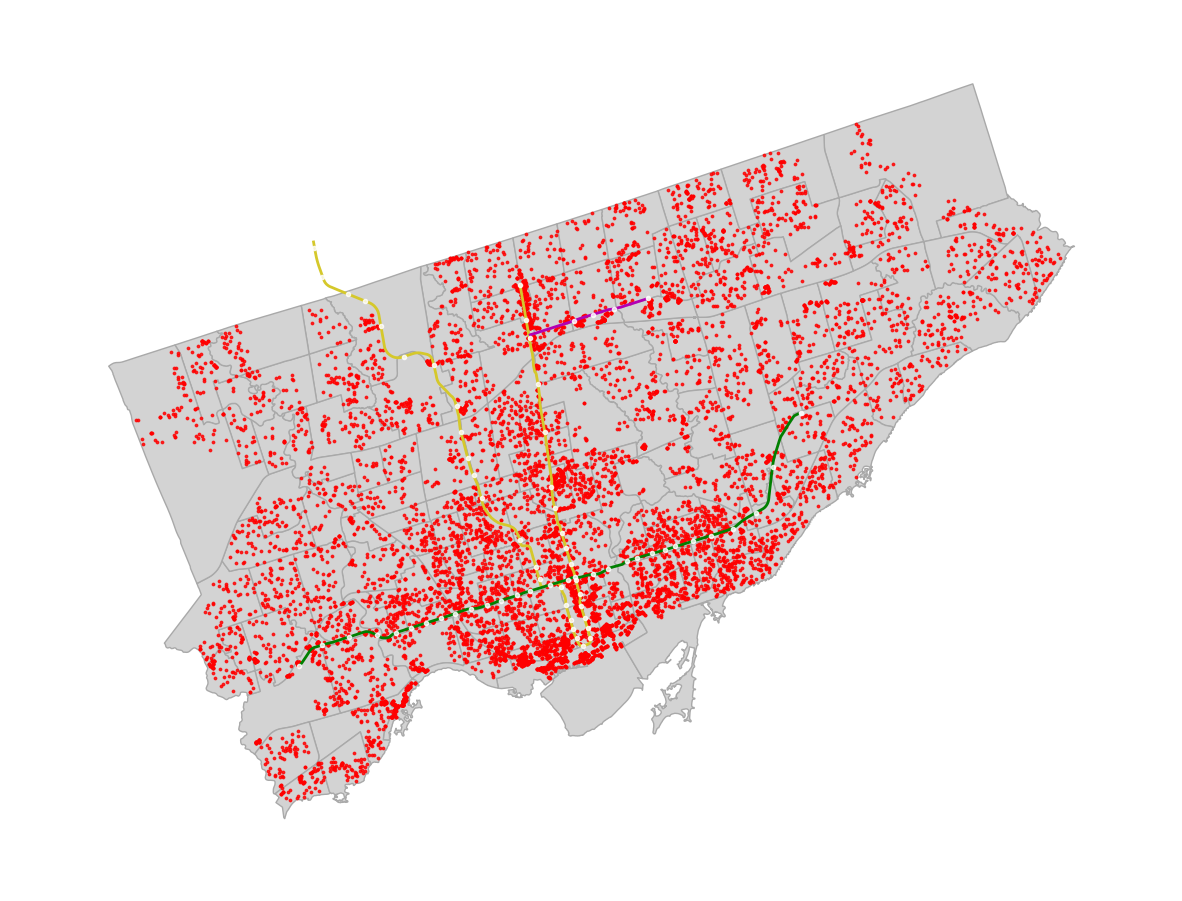

In [138]:
to = draw_toronto()

gdf_subway = get_transit_shape(subway_trips_shapes, shapes)

gdf_subway_stops = gpd.GeoDataFrame(
    subway_stops,
    geometry=gpd.points_from_xy(subway_stops["stop_lon"], subway_stops["stop_lat"]),
    crs=neighbourhoods.crs,
)

gdf_houses = gpd.GeoDataFrame(
    houses,
    geometry=gpd.points_from_xy(houses["lon"], houses["lat"]),
    crs=neighbourhoods.crs,
)

to.scatter(
    gdf_houses.geometry.x,
    gdf_houses.geometry.y,
    s=3,
    color="red",
    alpha=0.8,
    zorder=4,
    transform=ccrs.PlateCarree(),
)

to.scatter(
    gdf_subway_stops.geometry.x,
    gdf_subway_stops.geometry.y,
    s=9,
    color="white",
    alpha=0.8,
    zorder=5,
    transform=ccrs.PlateCarree(),
)

to.add_geometries(
    gdf_subway.geometry,
    crs=ccrs.PlateCarree(),
    facecolor="none",
    edgecolor=gdf_subway["route_color"],
    linewidth=2,
    zorder=4,
)

plt.show()

In [139]:
m = folium.Map(location=[43.7, -79.4], zoom_start=11)
folium.GeoJson(
    neighbourhoods.to_json(),
    style_function=lambda x: {
        "fillColor": "lightgray",
        "color": "black",
        "weight": 1,
        "fillOpacity": 0.5,
    },
).add_to(m)

for _, row in gdf_subway.iterrows():
    coords = [(lat, lon) for lon, lat in row.geometry.coords]
    folium.PolyLine(coords, color=row["route_color"], weight=4, opacity=0.8).add_to(m)

for _, stop in gdf_subway_stops.iterrows():
    folium.CircleMarker(
        location=[stop.geometry.y, stop.geometry.x],
        radius=1,
        color="white",
        fill=True,
        fill_color="white",
        fill_opacity=0.8,
    ).add_to(m)
    
folium.LayerControl().add_to(m)

m.save("toronto_map.html")
webbrowser.open("toronto_map.html")

True

# Census Data

In [140]:
profile_path = neighbourhood_path.joinpath("neighbourhood-profiles-2021-158-model.xlsx")

profile = pd.read_excel(profile_path)
profile = profile.set_index(profile.columns[0]).T

In [141]:
profile.head()

Neighbourhood Name,Neighbourhood Number,TSNS 2020 Designation,Total - Age groups of the population - 25% sample data,0 to 14 years,0 to 4 years,5 to 9 years,10 to 14 years,15 to 64 years,15 to 19 years,20 to 24 years,...,Between 9 a.m. and 11:59 a.m.,Between 12 p.m. and 4:59 a.m.,Total - Eligibility for instruction in the minority official language for the population in private households born in 2003 or later - 25% sample data,Children eligible for instruction in the minority official language,Children not eligible for instruction in the minority official language,"Total - Eligibility and instruction in the minority official language, for the population in private households born between 2003 and 2015 (inclusive) - 25% sample data",Children eligible for instruction in the minority official language,Eligible children who have been instructed in the minority official language at the primary or secondary level in Canada,Eligible children who have not been instructed in the minority official language at the primary or secondary level in Canada,Children not eligible for instruction in the minority official language
West Humber-Clairville,1,Not an NIA or Emerging Neighbourhood,33300,4295,1460,1345,1485,23640,1860,3175,...,1665,2935,5430,410,5020,3875,335,255,75,3540
Mount Olive-Silverstone-Jamestown,2,Neighbourhood Improvement Area,31345,5690,1650,1860,2175,21490,2280,2675,...,1145,2965,7285,510,6780,5540,395,245,145,5145
Thistletown-Beaumond Heights,3,Neighbourhood Improvement Area,9850,1495,505,540,455,6615,570,745,...,395,635,1860,180,1685,1325,120,75,45,1205
Rexdale-Kipling,4,Not an NIA or Emerging Neighbourhood,10375,1575,505,615,455,6950,515,715,...,425,775,1910,135,1770,1370,90,75,25,1275
Elms-Old Rexdale,5,Neighbourhood Improvement Area,9355,1610,440,480,685,6355,635,685,...,355,675,2015,95,1920,1520,70,60,10,1445


In [142]:
cols = []
for idx, col in enumerate(profile.columns):
    match = re.match("\\s+", col)
    indent = 0 if match is None else len(match.group())
    cols.append((idx, indent // 2, col[indent:]))

profile = profile.rename(columns={col: col.lstrip() for col in profile.columns})
profile = profile.convert_dtypes()

In [143]:
profile.info()

<class 'pandas.core.frame.DataFrame'>
Index: 158 entries, West Humber-Clairville to South Eglinton-Davisville
Columns: 2603 entries, Neighbourhood Number to Children not eligible for instruction in the minority official language
dtypes: Float64(45), Int64(2552), object(2), string(4)
memory usage: 3.5+ MB


In [144]:
profile.describe()

Neighbourhood Name,Neighbourhood Number,Total - Age groups of the population - 25% sample data,0 to 14 years,0 to 4 years,5 to 9 years,10 to 14 years,15 to 64 years,15 to 19 years,20 to 24 years,25 to 29 years,...,Between 9 a.m. and 11:59 a.m.,Between 12 p.m. and 4:59 a.m.,Total - Eligibility for instruction in the minority official language for the population in private households born in 2003 or later - 25% sample data,Children eligible for instruction in the minority official language,Children not eligible for instruction in the minority official language,"Total - Eligibility and instruction in the minority official language, for the population in private households born between 2003 and 2015 (inclusive) - 25% sample data",Children eligible for instruction in the minority official language,Eligible children who have been instructed in the minority official language at the primary or secondary level in Canada,Eligible children who have not been instructed in the minority official language at the primary or secondary level in Canada,Children not eligible for instruction in the minority official language
count,158.0,158.0,158.0,158.0,158.0,158.0,158.0,158.0,158.0,158.0,...,158.0,158.0,158.0,158.0,158.0,158.0,158.0,158.0,158.0,158.0
mean,88.107595,17476.518987,2425.949367,781.107595,815.316456,829.873418,12158.291139,846.962025,1167.721519,1535.506329,...,938.544304,865.601266,2982.278481,275.791139,2706.329114,2145.094937,210.126582,135.094937,74.968354,1934.71519
std,51.236381,6131.717523,1038.593511,323.027884,360.781478,392.259886,4547.972173,398.420382,616.792761,1057.438949,...,393.64672,554.919044,1296.000289,128.679628,1206.260265,985.927167,106.250439,72.217981,50.106564,908.210294
min,1.0,6260.0,505.0,165.0,185.0,120.0,4300.0,180.0,320.0,295.0,...,225.0,125.0,630.0,50.0,540.0,455.0,30.0,10.0,0.0,385.0
25%,43.25,12456.25,1571.25,507.5,535.0,541.25,8386.25,542.5,692.5,886.25,...,650.0,485.0,1916.25,185.0,1741.25,1380.0,131.25,81.25,40.0,1258.75
50%,88.5,16812.5,2245.0,722.5,760.0,760.0,11560.0,762.5,1085.0,1262.5,...,877.5,710.0,2730.0,252.5,2495.0,1932.5,190.0,115.0,65.0,1750.0
75%,133.75,22212.5,3068.75,990.0,1038.75,1127.5,15180.0,1100.0,1416.25,1917.5,...,1173.75,1131.25,3765.0,352.5,3431.25,2758.75,263.75,173.75,95.0,2522.5
max,174.0,33300.0,5690.0,1650.0,1860.0,2175.0,25015.0,2280.0,3810.0,7440.0,...,2100.0,2965.0,7285.0,660.0,6780.0,5540.0,570.0,375.0,240.0,5145.0


In [145]:
profile.isna().sum()

Neighbourhood Name
Neighbourhood Number                                                                                                                                                        0
TSNS 2020 Designation                                                                                                                                                       0
Total - Age groups of the population - 25% sample data                                                                                                                      0
0 to 14 years                                                                                                                                                               0
0 to 4 years                                                                                                                                                                0
                                                                                                               

In [146]:
sum(profile.isna().sum())

0

In [147]:
profile.iloc[:,[idx for idx, indent, _ in cols if indent == 0]]

Neighbourhood Name,Neighbourhood Number,TSNS 2020 Designation,Total - Age groups of the population - 25% sample data,Total - Distribution (%) of the population by broad age groups - 25% sample data,Average age of the population,Median age of the population,Total - Persons in private households - 25% sample data,Number of persons in private households,Total - Marital status for the total population aged 15 years and over - 25% sample data,Total - Income statistics in 2020 for the population aged 15 years and over in private households - 25% sample data,...,"Total - All languages used at work for the population in private households aged 15 years and over who worked since January 1, 2020 - 25% sample data","Total - Language used most often at work for the population aged 15 years and over who worked since January 1, 2020, in private households, 2021 Census - 25% sample data","Total - Other language(s) used regularly at work for the population in private households aged 15 years and over who worked since January 1, 2020 - 25% sample data",Total - Place of work status for the employed labour force aged 15 years and over - 25% sample data,Total - Commuting destination for the employed labour force aged 15 years and over with a usual place of work - 25% sample data,Total - Main mode of commuting for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data,Total - Commuting duration for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data,Total - Time leaving for work for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data,Total - Eligibility for instruction in the minority official language for the population in private households born in 2003 or later - 25% sample data,"Total - Eligibility and instruction in the minority official language, for the population in private households born between 2003 and 2015 (inclusive) - 25% sample data"
West Humber-Clairville,1,Not an NIA or Emerging Neighbourhood,33300,100,40.5,38.0,33300,33300,29000,29000,...,19485,19485,19485,15780,10290,12920,12920,12920,5430,3875
Mount Olive-Silverstone-Jamestown,2,Neighbourhood Improvement Area,31345,100,37.8,36.0,31345,31345,25660,25660,...,15240,15240,15240,11830,8215,10125,10125,10125,7285,5540
Thistletown-Beaumond Heights,3,Neighbourhood Improvement Area,9850,100,41.0,39.2,9850,9850,8355,8355,...,5155,5155,5155,4165,2515,3365,3365,3365,1860,1325
Rexdale-Kipling,4,Not an NIA or Emerging Neighbourhood,10375,100,41.9,42.0,10375,10375,8800,8800,...,5630,5630,5630,4560,2880,3680,3680,3680,1910,1370
Elms-Old Rexdale,5,Neighbourhood Improvement Area,9355,100,39.6,38.4,9355,9355,7745,7745,...,4545,4545,4545,3600,2345,2965,2965,2965,2015,1520
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Yonge-Bay Corridor,170,Not an NIA or Emerging Neighbourhood,12645,100,34.5,31.0,12645,12645,11680,11680,...,8995,8995,8995,7475,2905,3240,3240,3240,1075,555
Junction-Wallace Emerson,171,Not an NIA or Emerging Neighbourhood,23180,100,39.6,37.6,23180,23180,20100,20100,...,14710,14710,14710,12070,5260,6925,6925,6925,3580,2375
Dovercourt Village,172,Not an NIA or Emerging Neighbourhood,12380,100,41.9,39.2,12380,12380,11015,11015,...,7925,7925,7925,6430,2775,3495,3495,3495,1665,1190
North Toronto,173,Not an NIA or Emerging Neighbourhood,15885,100,39.2,35.2,15885,15885,14570,14570,...,11400,11400,11400,9460,3880,4540,4540,4540,1620,1050


In [148]:
# profile[profile["Neighbourhood Name"] == "Rexdale-Kipling"]
profile.loc["Neighbourhood Name"]

KeyError: 'Neighbourhood Name'